In [2]:
# Import libraries\nimport pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nimport warnings\nwarnings.filterwarnings('ignore')\n\nplt.style.use('seaborn-v0_8-darkgrid')\nsns.set_palette('husl')\n%matplotlib inline

In [3]:
# Load data\ndf = pd.read_csv('../data/raw/sample_user_data.csv')\nprint(f'Shape: {df.shape}')\ndf.head()

In [4]:
# Risk distribution\nrisk_counts = df['burnout_risk'].value_counts()\nprint(risk_counts)\n\nfig, axes = plt.subplots(1, 2, figsize=(12, 5))\naxes[0].bar(risk_counts.index, risk_counts.values)\naxes[1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%')\nplt.show()

In [5]:
!pip install matplotlib seaborn

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [7]:
# Load the dataset
df = pd.read_csv('../data/raw/sample_user_data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (28, 11)


,user_id,date,sleep_hours,workload_hours,stress_level,screen_time,physical_activity,social_interaction,meal_quality,productivity_score,burnout_risk
0,1,2024-01-01,7.5,8,4,6,45,3.0,8,8,Low
1,1,2024-01-02,7.0,9,5,7,30,2.0,7,7,Low
2,1,2024-01-03,6.5,10,7,8,20,1.5,6,6,Medium
3,1,2024-01-04,6.0,11,8,9,15,1.0,5,5,Medium
4,1,2024-01-05,5.0,12,9,10,10,0.5,4,4,High


In [8]:
# Basic dataset information
print("Dataset Info:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nStatistical Summary:")
df.describe()

Dataset Info:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             28 non-null     int64  
 1   date                28 non-null     object 
 2   sleep_hours         28 non-null     float64
 3   workload_hours      28 non-null     int64  
 4   stress_level        28 non-null     int64  
 5   screen_time         28 non-null     int64  
 6   physical_activity   28 non-null     int64  
 7   social_interaction  28 non-null     float64
 8   meal_quality        28 non-null     int64  
 9   productivity_score  28 non-null     int64  
 10  burnout_risk        28 non-null     object 
dtypes: float64(2), int64(7), object(2)
memory usage: 2.5+ KB

Missing values:
user_id               0
date                  0
sleep_hours           0
workload_hours        0
stress_level          0
screen_time           0
physical_activity     0
social_intera

,user_id,sleep_hours,workload_hours,stress_level,screen_time,physical_activity,social_interaction,meal_quality,productivity_score
count,28.000000,28.00000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,2.892857,6.50000,9.321429,6.250000,7.500000,33.928571,2.250000,6.178571,6.178571
std,1.423071,1.30526,2.553916,2.204793,2.333333,23.188325,1.350583,2.000992,2.000992
min,1.000000,4.00000,4.000000,2.000000,3.000000,0.000000,0.000000,2.000000,2.000000
25%,2.000000,5.50000,7.750000,4.750000,6.000000,15.000000,1.375000,5.000000,5.000000
50%,3.000000,6.50000,9.500000,6.000000,7.500000,30.000000,2.000000,6.000000,6.000000
75%,4.000000,7.50000,11.000000,8.000000,9.000000,46.250000,3.125000,8.000000,8.000000
max,5.000000,9.00000,14.000000,10.000000,12.000000,90.000000,5.000000,10.000000,10.000000


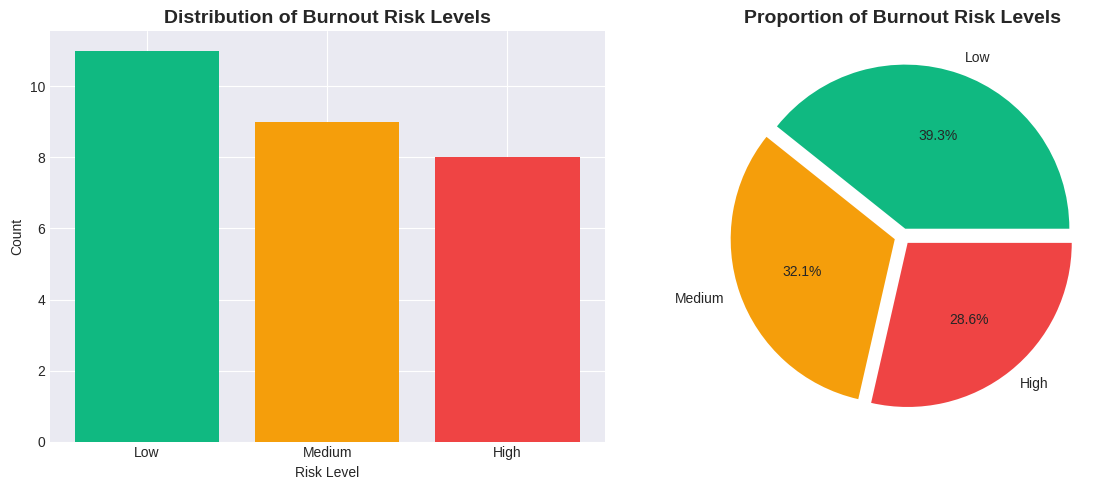


Risk Level Distribution:
  Low: 11 samples (39.3%)
  Medium: 9 samples (32.1%)
  High: 8 samples (28.6%)


In [9]:
# Distribution of burnout risk levels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
risk_counts = df['burnout_risk'].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values, color=['#10b981', '#f59e0b', '#ef4444'])
axes[0].set_title('Distribution of Burnout Risk Levels', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', 
            colors=['#10b981', '#f59e0b', '#ef4444'], explode=(0.05, 0.05, 0.05))
axes[1].set_title('Proportion of Burnout Risk Levels', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRisk Level Distribution:")
for risk, count in risk_counts.items():
    print(f"  {risk}: {count} samples ({count/len(df)*100:.1f}%)")

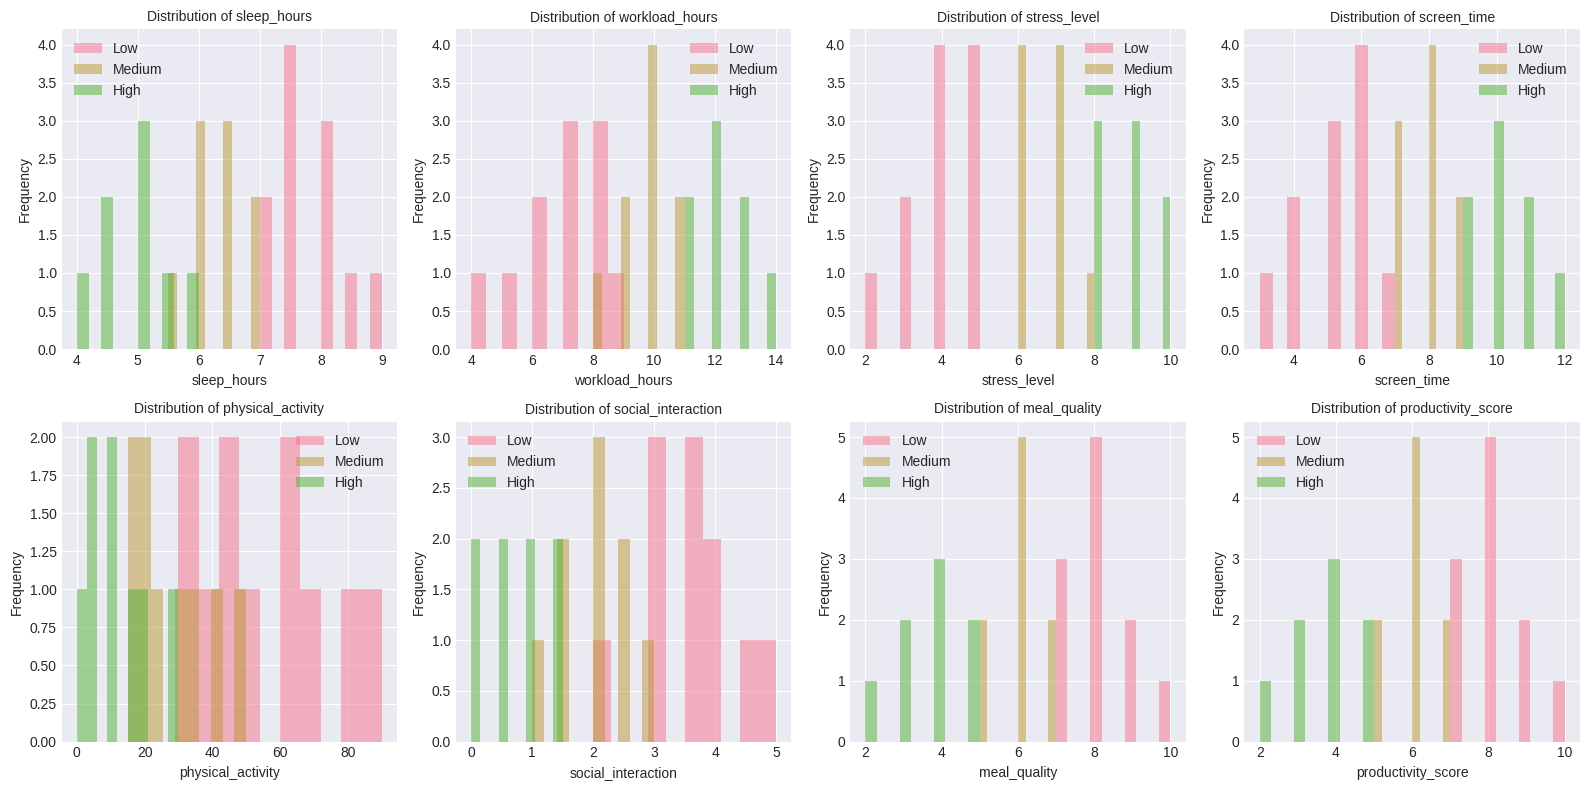

In [10]:
# Feature distributions by risk level
features = ['sleep_hours', 'workload_hours', 'stress_level', 'screen_time', 
            'physical_activity', 'social_interaction', 'meal_quality', 'productivity_score']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    for risk in ['Low', 'Medium', 'High']:
        data = df[df['burnout_risk'] == risk][feature]
        axes[i].hist(data, alpha=0.5, label=risk, bins=10)
    axes[i].set_title(f'Distribution of {feature}', fontsize=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [11]:
# Average feature values by risk level
risk_avg = df.groupby('burnout_risk')[features].mean()
print("Average feature values by risk level:")
risk_avg

Average feature values by risk level:


,sleep_hours,workload_hours,stress_level,screen_time,physical_activity,social_interaction,meal_quality,productivity_score
burnout_risk,,,,,,,,
High,4.937500,12.250000,8.875000,10.250000,11.875000,0.750000,3.750000,3.750000
Low,7.772727,6.818182,4.000000,5.181818,55.000000,3.545455,8.090909,8.090909
Medium,6.333333,9.777778,6.666667,7.888889,27.777778,2.000000,6.000000,6.000000


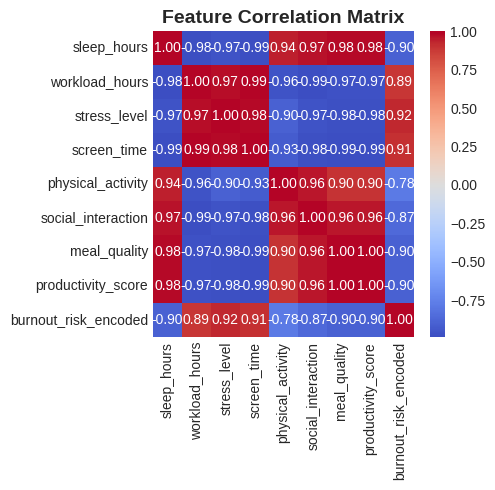


Top factors correlated with burnout risk:
  stress_level: 0.924
  screen_time: 0.906
  workload_hours: 0.889
  physical_activity: -0.784
  social_interaction: -0.865
  meal_quality: -0.900
  productivity_score: -0.900
  sleep_hours: -0.904


In [12]:
# Correlation heatmap
df_numeric = df.copy()
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_numeric['burnout_risk_encoded'] = df_numeric['burnout_risk'].map(risk_mapping)

plt.figure(figsize=(5, 5))
correlation_matrix = df_numeric[features + ['burnout_risk_encoded']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop factors correlated with burnout risk:")
correlations = correlation_matrix['burnout_risk_encoded'].drop('burnout_risk_encoded').sort_values(ascending=False)
for feature, corr in correlations.items():
    print(f"  {feature}: {corr:.3f}")